## Introduction

##This project explores CO₂ emissions levels and fuel consumption characteristics of gas-powered cars. We use a dataset that consists of 1000 vehicles with measurements of a variety of characteristics such as engine size, vehicle class, transmission type, and fuel type; to investigate relationships between factors affecting pollution levels, and fuel efficiency.

##We test 5 hypotheses relating vehicle characteristics and environmental impact measures. We employ various statistical techniques: ANOVA, Z-test and chi-square tests.

##Data Visualization

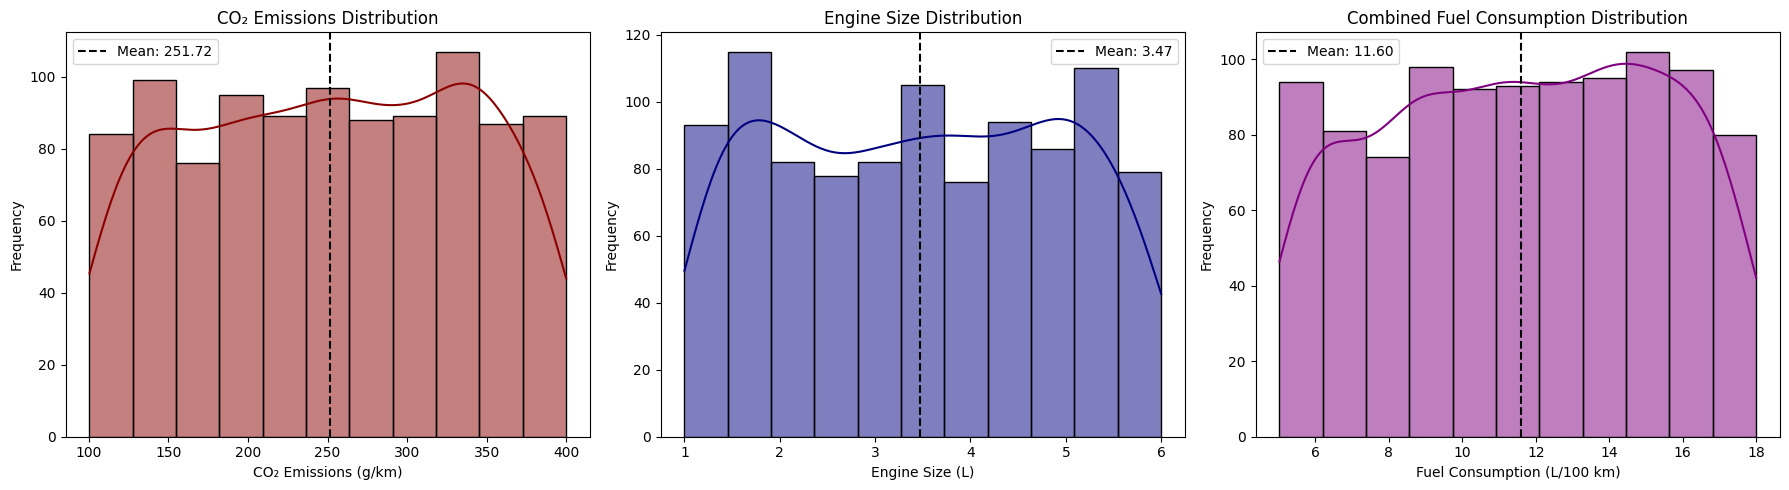

In [ ]:
# Create a figure with 3 subplots in a row
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot histograms with KDE curves
sns.histplot(df['CO2 Emissions (g/km)'], kde=True, color='darkred', ax=axes[0])
axes[0].set_title('CO₂ Emissions Distribution')
axes[0].set_xlabel('CO₂ Emissions (g/km)')
axes[0].set_ylabel('Frequency')

sns.histplot(df['Engine Size (L)'], kde=True, color='navy', ax=axes[1])
axes[1].set_title('Engine Size Distribution')
axes[1].set_xlabel('Engine Size (L)')
axes[1].set_ylabel('Frequency')

sns.histplot(df['Fuel Consumption Comb (L/100 km)'], kde=True, color='purple', ax=axes[2])
axes[2].set_title('Combined Fuel Consumption Distribution')
axes[2].set_xlabel('Fuel Consumption (L/100 km)')
axes[2].set_ylabel('Frequency')

# Add mean lines
for i, col in enumerate(['CO2 Emissions (g/km)', 'Engine Size (L)', 'Fuel Consumption Comb (L/100 km)']):
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='black', linestyle='--',
                   label=f'Mean: {mean_val:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

<ipython-input-25-57a7b1c5ef3f>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Vehicle Class', y='CO2 Emissions (g/km)', data=df, errorbar=('ci', 95), ax=axes[0], palette='viridis')
<ipython-input-25-57a7b1c5ef3f>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Transmission Type', y='CO2 Emissions (g/km)', data=df, errorbar=('ci', 95), ax=axes[1], palette=['#1f77b4', '#ff7f0e'])
<ipython-input-25-57a7b1c5ef3f>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fuel Type', y='CO2 Emissions (g/km)', data=df, errorbar=('ci', 95), ax

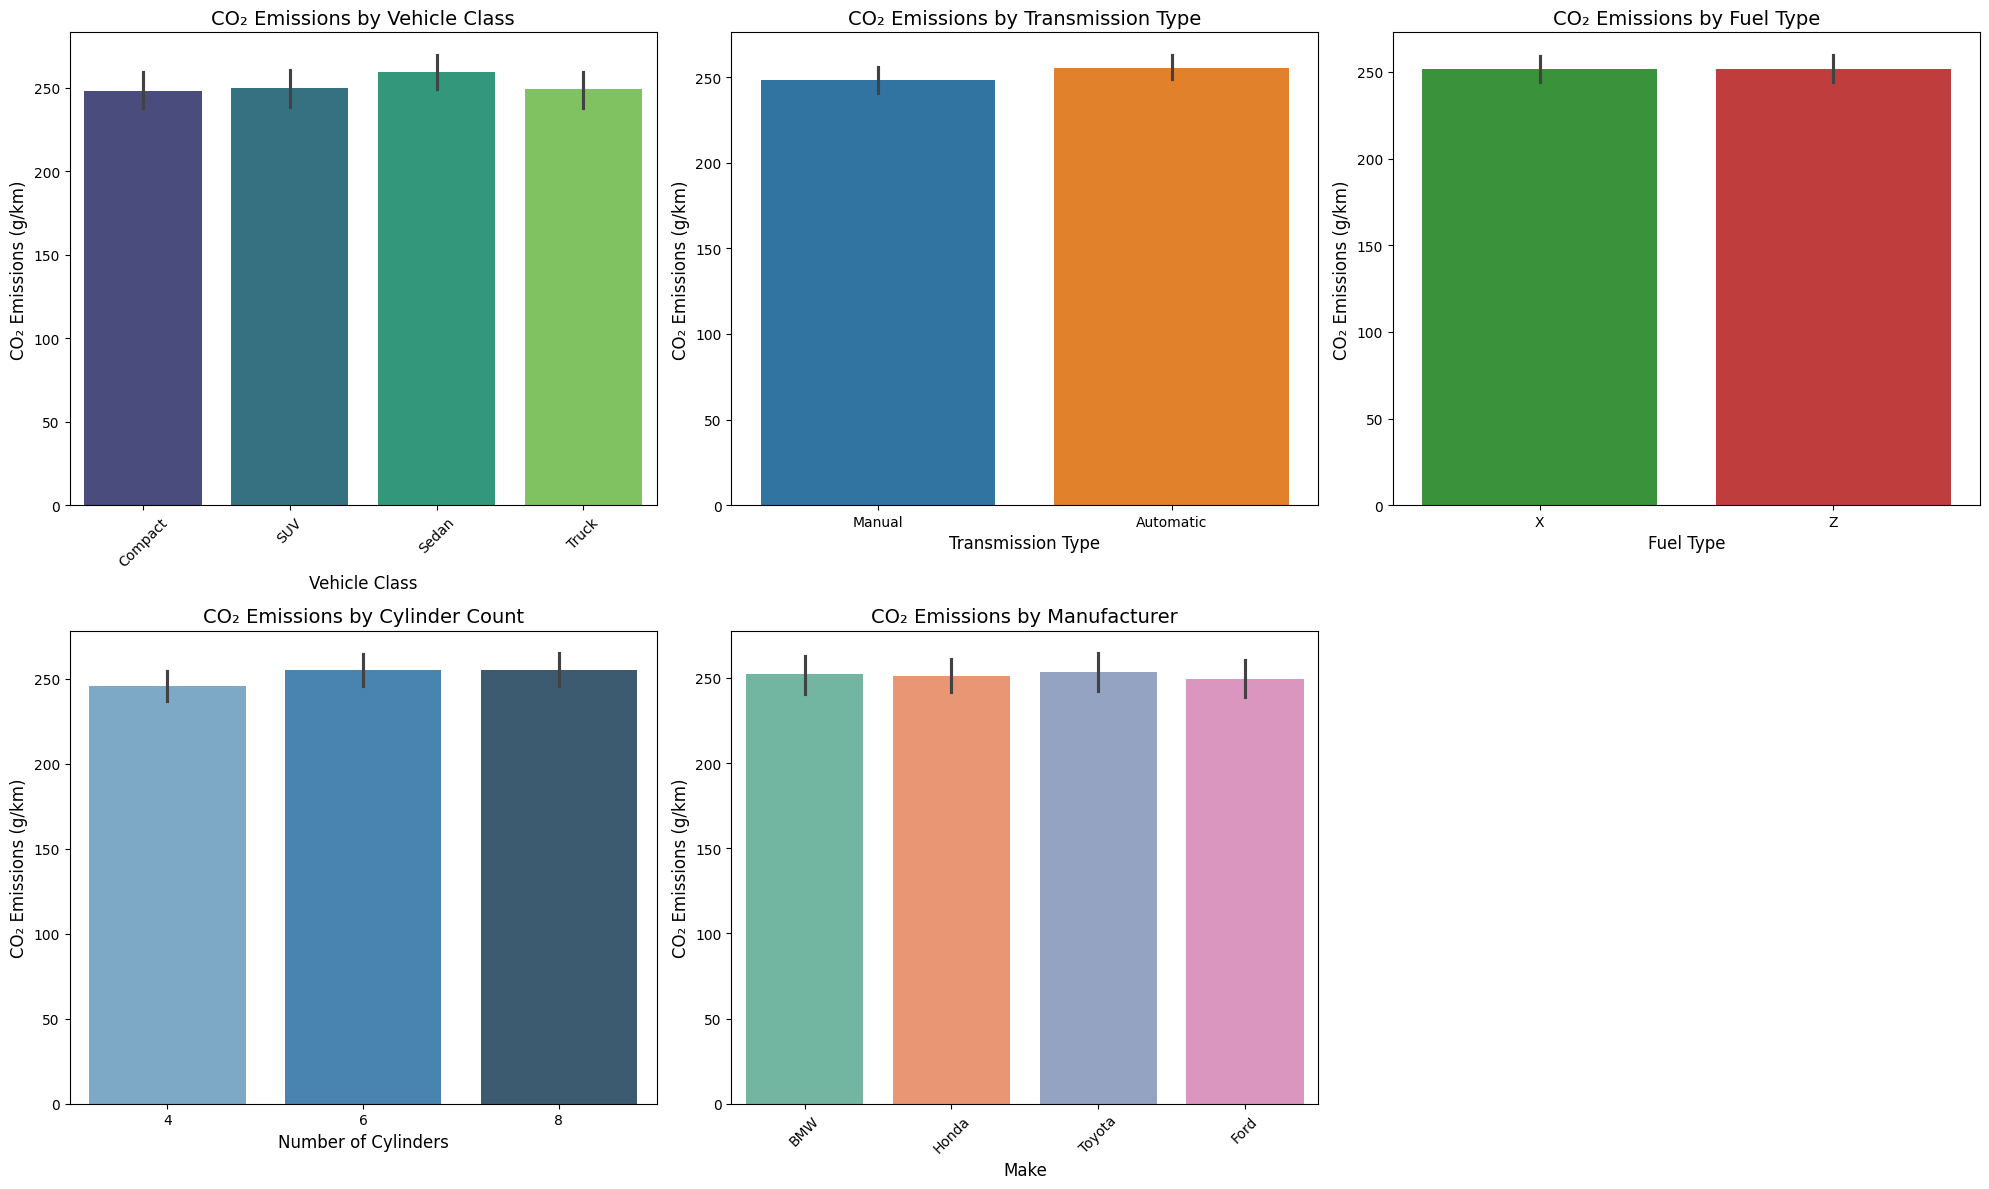

In [ ]:
# Create a figure with multiple subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Plot bar charts
sns.barplot(x='Vehicle Class', y='CO2 Emissions (g/km)', data=df, errorbar=('ci', 95), ax=axes[0], palette='viridis')
axes[0].set_title('CO₂ Emissions by Vehicle Class', fontsize=14)
axes[0].set_xlabel('Vehicle Class', fontsize=12)
axes[0].set_ylabel('CO₂ Emissions (g/km)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x='Transmission Type', y='CO2 Emissions (g/km)', data=df, errorbar=('ci', 95), ax=axes[1], palette=['#1f77b4', '#ff7f0e'])
axes[1].set_title('CO₂ Emissions by Transmission Type', fontsize=14)
axes[1].set_xlabel('Transmission Type', fontsize=12)
axes[1].set_ylabel('CO₂ Emissions (g/km)', fontsize=12)

sns.barplot(x='Fuel Type', y='CO2 Emissions (g/km)', data=df, errorbar=('ci', 95), ax=axes[2], palette=['#2ca02c', '#d62728'])
axes[2].set_title('CO₂ Emissions by Fuel Type', fontsize=14)
axes[2].set_xlabel('Fuel Type', fontsize=12)
axes[2].set_ylabel('CO₂ Emissions (g/km)', fontsize=12)

sns.barplot(x='Cylinders', y='CO2 Emissions (g/km)', data=df, errorbar=('ci', 95), ax=axes[3], palette='Blues_d')
axes[3].set_title('CO₂ Emissions by Cylinder Count', fontsize=14)
axes[3].set_xlabel('Number of Cylinders', fontsize=12)
axes[3].set_ylabel('CO₂ Emissions (g/km)', fontsize=12)

sns.barplot(x='Make', y='CO2 Emissions (g/km)', data=df, errorbar=('ci', 95), ax=axes[4], palette='Set2')
axes[4].set_title('CO₂ Emissions by Manufacturer', fontsize=14)
axes[4].set_xlabel('Make', fontsize=12)
axes[4].set_ylabel('CO₂ Emissions (g/km)', fontsize=12)
axes[4].tick_params(axis='x', rotation=45)

# Remove the empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

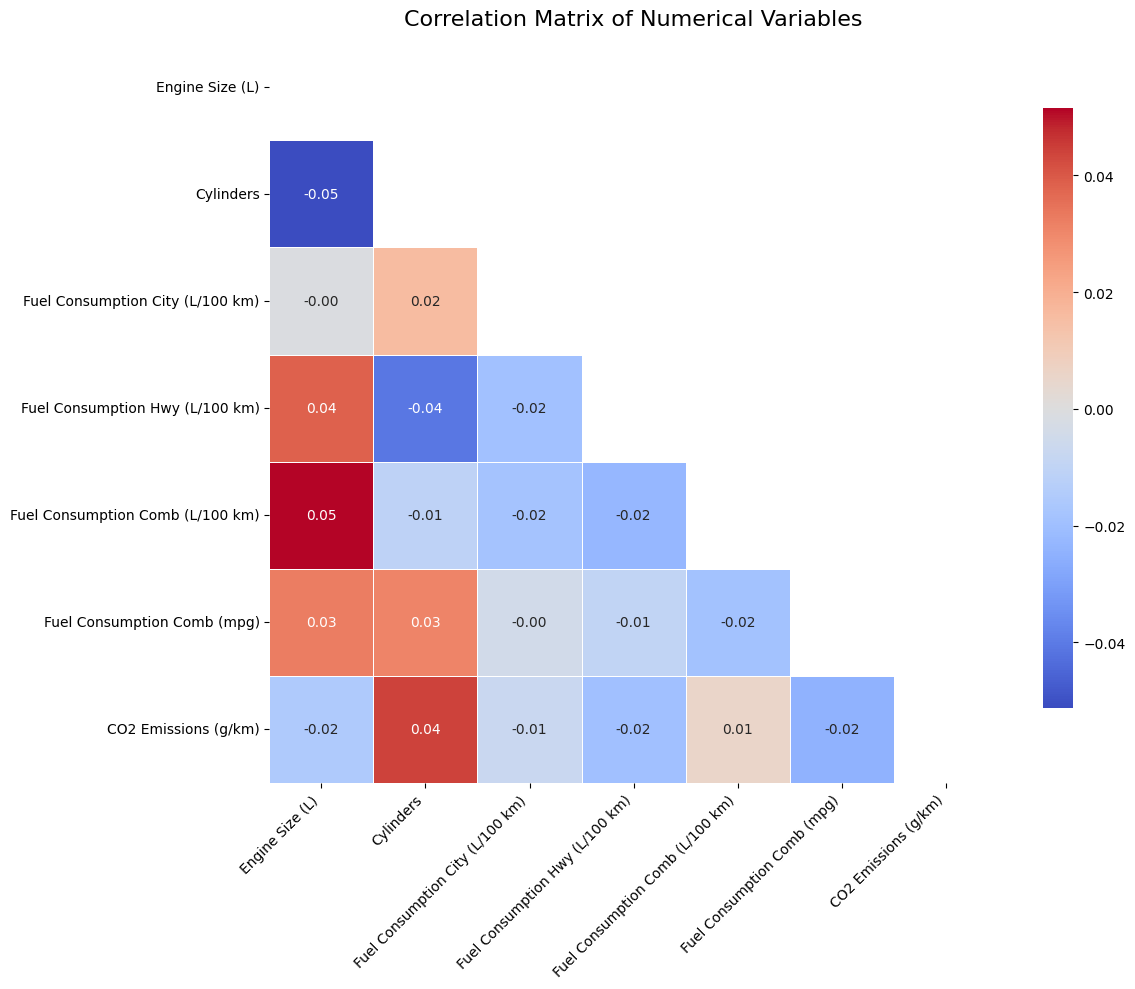

In [ ]:
plt.figure(figsize=(12, 10))
# Select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation = numeric_df.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(correlation, dtype=bool))

# Generate heatmap with mask
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', mask=mask,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Variables', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

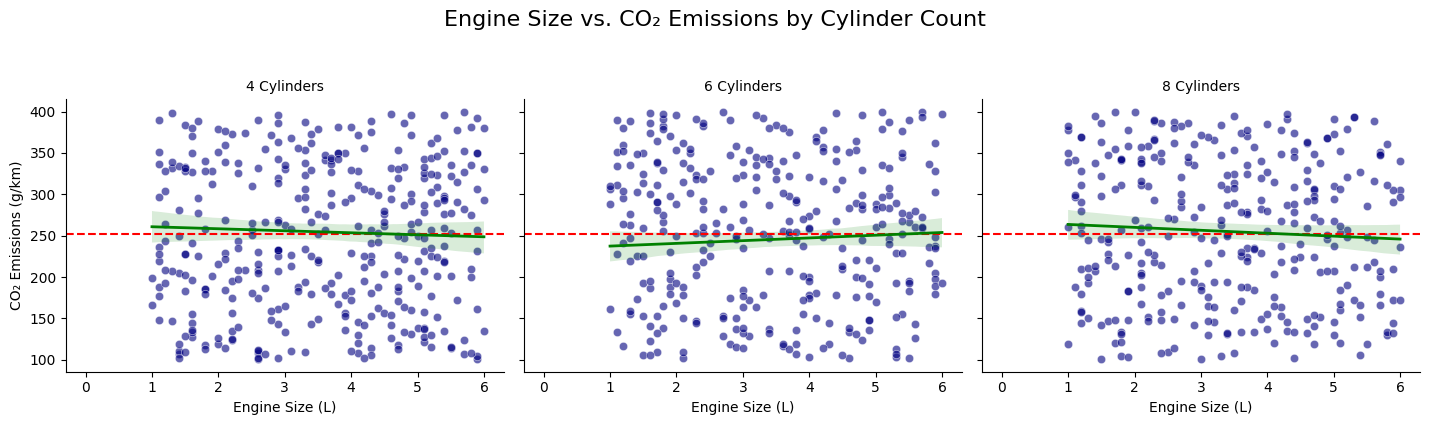

In [ ]:
g = sns.FacetGrid(data=df, col='Cylinders', height=4, aspect=1.2)
g.map_dataframe(sns.scatterplot, x="Engine Size (L)", y="CO2 Emissions (g/km)", color='navy', alpha=0.6)
g.map(plt.axline, xy1=(0, df['CO2 Emissions (g/km)'].mean()), slope=0, linestyle='--', color='red', label='Mean CO₂')

# Add regression line to each facet
for i, ax in enumerate(g.axes.flat):
    subset = df[df['Cylinders'] == df['Cylinders'].unique()[i]]
    if len(subset) > 1:  # Ensure we have enough data points
        sns.regplot(x='Engine Size (L)', y='CO2 Emissions (g/km)',
                   data=subset, ax=ax, scatter=False,
                   line_kws={'color':'green', 'linewidth':2})

g.set_axis_labels("Engine Size (L)", "CO₂ Emissions (g/km)")
g.set_titles(col_template="{col_name} Cylinders")
g.fig.suptitle('Engine Size vs. CO₂ Emissions by Cylinder Count', y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

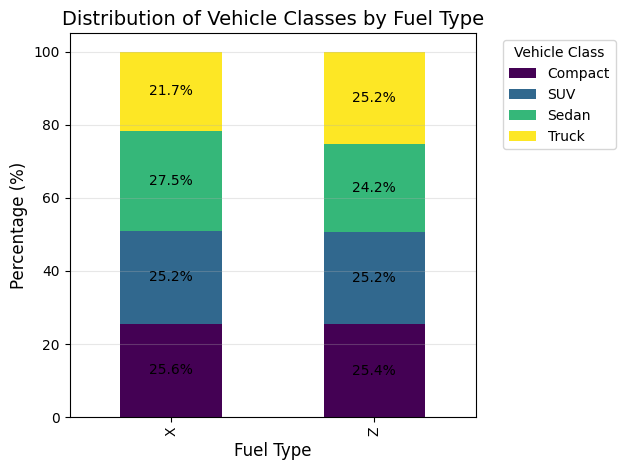

In [ ]:
# Create a contingency table
contingency = pd.crosstab(df['Fuel Type'], df['Vehicle Class'])
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
plt.figure(figsize=(12, 7))
contingency_pct.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Distribution of Vehicle Classes by Fuel Type', fontsize=14)
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Vehicle Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)

# Add percentage labels
for i, fuel_type in enumerate(contingency_pct.index):
    total = 0
    for j, vehicle_class in enumerate(contingency_pct.columns):
        value = contingency_pct.loc[fuel_type, vehicle_class]
        if value > 5:  # Only show labels for segments > 5%
            plt.text(i, total + value/2, f'{value:.1f}%', ha='center', va='center')
        total += value

plt.tight_layout()
plt.show()

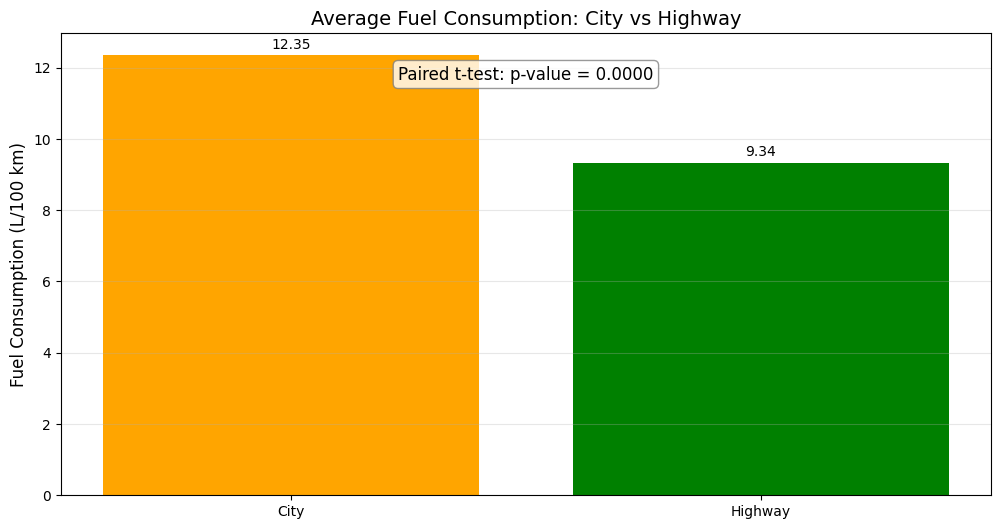

In [ ]:
plt.figure(figsize=(12, 6))

# Create paired bar chart
city_mean = df['Fuel Consumption City (L/100 km)'].mean()
hwy_mean = df['Fuel Consumption Hwy (L/100 km)'].mean()
labels = ['City', 'Highway']
values = [city_mean, hwy_mean]

bars = plt.bar(labels, values, color=['orange', 'green'])

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}', ha='center', va='bottom')

plt.title('Average Fuel Consumption: City vs Highway', fontsize=14)
plt.ylabel('Fuel Consumption (L/100 km)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Add paired t-test results
t_stat, p_val = stats.ttest_rel(df['Fuel Consumption City (L/100 km)'], df['Fuel Consumption Hwy (L/100 km)'])
plt.annotate(f'Paired t-test: p-value = {p_val:.4f}', xy=(0.5, 0.9), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
             ha='center', fontsize=12)

plt.show()

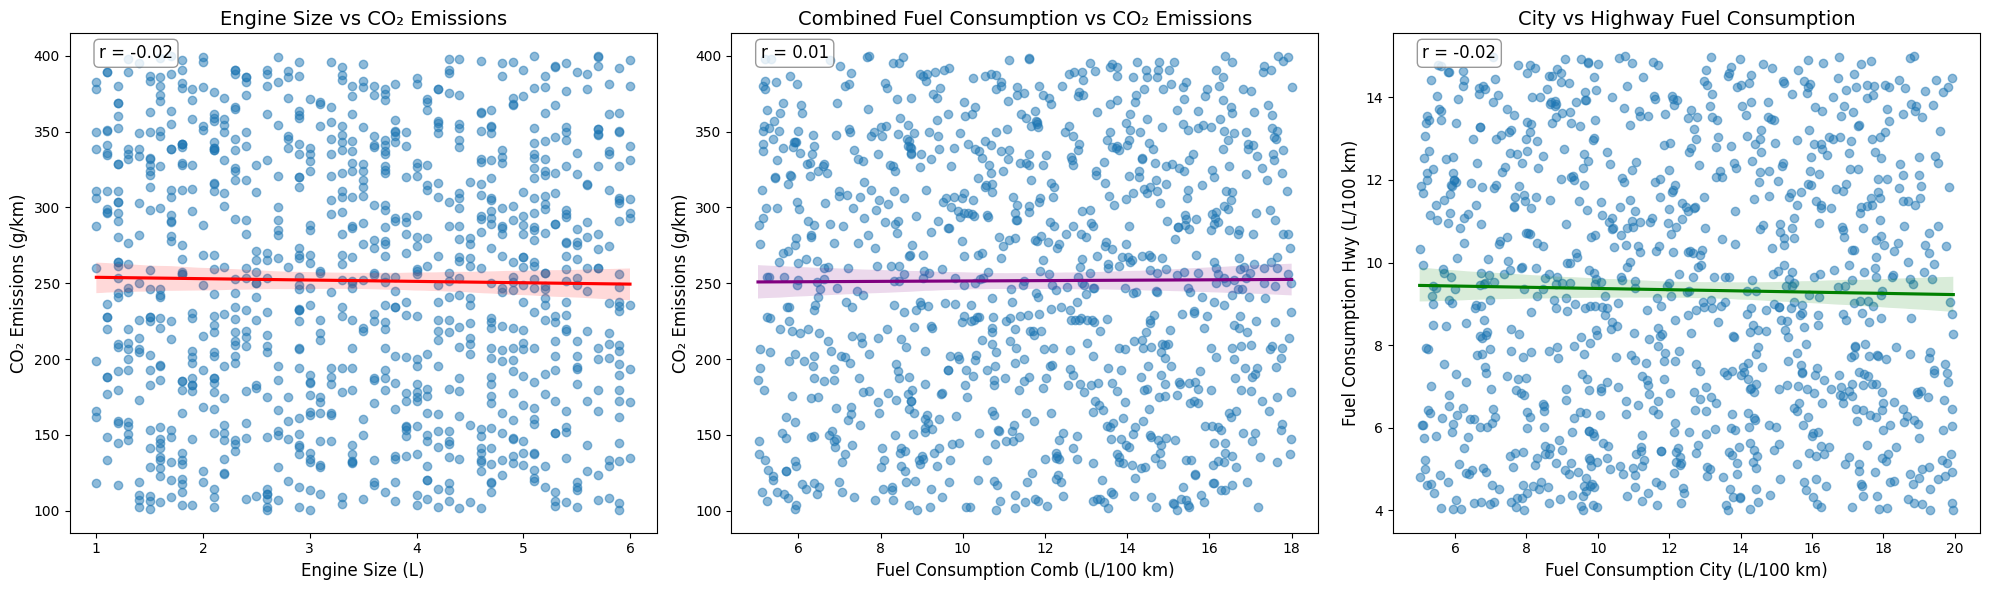

In [ ]:
# Create a figure with multiple subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot scatter with regression lines
sns.regplot(x='Engine Size (L)', y='CO2 Emissions (g/km)', data=df, ax=axes[0], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[0].set_title('Engine Size vs CO₂ Emissions', fontsize=14)
axes[0].set_xlabel('Engine Size (L)', fontsize=12)
axes[0].set_ylabel('CO₂ Emissions (g/km)', fontsize=12)
corr1 = df['Engine Size (L)'].corr(df['CO2 Emissions (g/km)'])
axes[0].annotate(f'r = {corr1:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

sns.regplot(x='Fuel Consumption Comb (L/100 km)', y='CO2 Emissions (g/km)', data=df, ax=axes[1], scatter_kws={'alpha':0.5}, line_kws={'color':'purple'})
axes[1].set_title('Combined Fuel Consumption vs CO₂ Emissions', fontsize=14)
axes[1].set_xlabel('Fuel Consumption Comb (L/100 km)', fontsize=12)
axes[1].set_ylabel('CO₂ Emissions (g/km)', fontsize=12)
corr2 = df['Fuel Consumption Comb (L/100 km)'].corr(df['CO2 Emissions (g/km)'])
axes[1].annotate(f'r = {corr2:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

sns.regplot(x='Fuel Consumption City (L/100 km)', y='Fuel Consumption Hwy (L/100 km)', data=df, ax=axes[2], scatter_kws={'alpha':0.5}, line_kws={'color':'green'})
axes[2].set_title('City vs Highway Fuel Consumption', fontsize=14)
axes[2].set_xlabel('Fuel Consumption City (L/100 km)', fontsize=12)
axes[2].set_ylabel('Fuel Consumption Hwy (L/100 km)', fontsize=12)
corr3 = df['Fuel Consumption City (L/100 km)'].corr(df['Fuel Consumption Hwy (L/100 km)'])
axes[2].annotate(f'r = {corr3:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.show()

## CO₂ Emissions Analysis of Gas-Powered Vehicles
This project analyzes the pollution and fuel consumption patterns of gasoline-powered vehicles. We'll test multiple hypotheses using statistical techniques.


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols


# Load dataset
file_path = '/content/Fuel_Consumption_and_CO2_Emissions.csv'
df = pd.read_csv(file_path)
df.head()


,Make,Model,Vehicle Class,Engine Size (L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions (g/km)
0,BMW,Model B,Compact,2.9,8,M5,X,15.18,12.42,17.54,31.42,335.36
1,Honda,Model C,SUV,1.6,4,M6,Z,13.89,4.87,14.33,16.93,127.99
2,Toyota,Model A,SUV,5.9,4,A8,Z,7.23,4.52,17.90,34.28,256.26
3,BMW,Model A,SUV,1.1,4,A6,X,7.58,4.21,14.08,32.63,350.92
4,BMW,Model A,Sedan,4.7,8,M6,Z,18.18,6.08,8.82,41.87,349.06


In [4]:
# Simplify transmission types
df['Transmission Type'] = df['Transmission'].apply(lambda x: 'Manual' if 'M' in x else 'Automatic')

# Drop any missing values (if any)
df = df.dropna()

# Summary
df.head()


,Make,Model,Vehicle Class,Engine Size (L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions (g/km),Transmission Type
0,BMW,Model B,Compact,2.9,8,M5,X,15.18,12.42,17.54,31.42,335.36,Manual
1,Honda,Model C,SUV,1.6,4,M6,Z,13.89,4.87,14.33,16.93,127.99,Manual
2,Toyota,Model A,SUV,5.9,4,A8,Z,7.23,4.52,17.90,34.28,256.26,Automatic
3,BMW,Model A,SUV,1.1,4,A6,X,7.58,4.21,14.08,32.63,350.92,Automatic
4,BMW,Model A,Sedan,4.7,8,M6,Z,18.18,6.08,8.82,41.87,349.06,Manual


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              1000 non-null   object 
 1   Model                             1000 non-null   object 
 2   Vehicle Class                     1000 non-null   object 
 3   Engine Size (L)                   1000 non-null   float64
 4   Cylinders                         1000 non-null   int64  
 5   Transmission                      1000 non-null   object 
 6   Fuel Type                         1000 non-null   object 
 7   Fuel Consumption City (L/100 km)  1000 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   1000 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  1000 non-null   float64
 10  Fuel Consumption Comb (mpg)       1000 non-null   float64
 11  CO2 Emissions (g/km)              1000 non-null   float64
 12  Transmi

In [6]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nUnique Values in Categorical Variables:")
for col in ['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type']:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts())

Dataset Shape: (1000, 13)

Data Types:
Make                                 object
Model                                object
Vehicle Class                        object
Engine Size (L)                     float64
Cylinders                             int64
Transmission                         object
Fuel Type                            object
Fuel Consumption City (L/100 km)    float64
Fuel Consumption Hwy (L/100 km)     float64
Fuel Consumption Comb (L/100 km)    float64
Fuel Consumption Comb (mpg)         float64
CO2 Emissions (g/km)                float64
Transmission Type                    object
dtype: object

Unique Values in Categorical Variables:

Make: 4 unique values
Make
Honda     280
Toyota    258
BMW       232
Ford      230
Name: count, dtype: int64

Model: 3 unique values
Model
Model A    341
Model B    331
Model C    328
Name: count, dtype: int64

Vehicle Class: 4 unique values
Vehicle Class
Sedan      258
Compact    255
SUV        252
Truck      235
Name: count, dtyp

In [7]:
df.isnull().sum()

,0
Make,0
Model,0
Vehicle Class,0
Engine Size (L),0
Cylinders,0
Transmission,0
Fuel Type,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0


## Hypothesis Testing

In [8]:
# HYPOTHESIS 1: Effect of Number of Cylinders on CO₂ Emissions (4 vs 6 cylinders)
# Null Hypothesis (H₀): There is no significant difference in mean CO₂ emissions (g/km) between vehicles with 4 cylinders and vehicles with 6 cylinders.
# Alternative Hypothesis (H₁): There is a significant difference in mean CO₂ emissions (g/km)  between vehicles with 4 cylinders and vehicles with 6 cylinders.

alpha = 0.05

group1 = df[df['Cylinders'] == 4]['CO2 Emissions (g/km)']
group2 = df[df['Cylinders'] == 6]['CO2 Emissions (g/km)']

n1 = len(group1)
n2 = len(group2)

mean1 = np.mean(group1)
mean2 = np.mean(group2)

std1 = np.std(group1, ddof=1)
std2 = np.std(group2, ddof=1)

se = np.sqrt((std1**2 / n1) + (std2**2 / n2))

z_stat = (mean1 - mean2) / se

p_val = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"H1 - Z-test for CO₂ emissions between 4 vs 6 cylinders:\nZ-stat: {z_stat:.3f}, P-value: {p_val:.3f}")

if p_val < alpha:
    print("Reject the null hypothesis: There is a significant difference in CO₂ emissions between 4-cylinder and 6-cylinder vehicles")
else:
    print("Fail to reject the null hypothesis: No significant difference detected in CO₂ emissions between 4-cylinder and 6-cylinder vehicles")



H1 - Z-test for CO₂ emissions between 4 vs 6 cylinders:
Z-stat: -1.382, P-value: 0.167
Fail to reject the null hypothesis: No significant difference detected in CO₂ emissions between 4-cylinder and 6-cylinder vehicles


In [10]:
# HYPOTHESIS 2: Relationship between Engine Size and CO₂ Emissions
# Null Hypothesis (H₀): There is no significant linear relationship between engine size (in liters) and CO₂ emissions (in g/km) in gas-powered vehicles.
# Alternative Hypothesis (H₁): There is a significant linear relationship between engine size (in liters) and CO₂ emissions (g/km) in gas-powered vehicles.

alpha = 0.05

groups = [group['CO2 Emissions (g/km)'] for name, group in df.groupby('Engine Size (L)')]

f_stat, p_val = stats.f_oneway(*groups)

print(f"H3 - ANOVA test for CO₂ emissions by engine size groups:")
print(f"F-stat: {f_stat:.3f}, P-value: {p_val:.3f}")

if p_val < alpha:
    print("Reject the null hypothesis: At least one engine size group differs significantly in CO₂ emissions.")
else:
    print("Fail to reject the null hypothesis: No significant difference in CO₂ emissions among engine size groups.")



H3 - ANOVA test for CO₂ emissions by engine size groups:
F-stat: 0.705, P-value: 0.940
Fail to reject the null hypothesis: No significant difference in CO₂ emissions among engine size groups.


In [ ]:
# HYPOTHESIS 3: Difference in CO₂ Emissions between Vehicle Classes
# Null Hypothesis (H₀): There is no significant difference in mean CO₂ emissions (g/km) among different vehicle classes (SUV, Sedan, Compact, Truck).
# Alternative Hypothesis (H₁): There is a significant difference in mean CO₂ emissions (g/km) among at least two vehicle classes (SUV, Sedan, Compact, Truck).

alpha=0.05

model = ols('Q("CO2 Emissions (g/km)") ~ Q("Vehicle Class")', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("H4 - ANOVA: CO2 Emissions by Vehicle Class")
print(anova_table)

p_val = anova_table['PR(>F)'][0]  # Extract p-value from ANOVA table
if p_val < alpha:
    print("Reject the null hypothesis: There are significant differences in CO₂ emissions between at least two vehicle classes")
    print("Post-hoc tests would be needed to determine which specific classes differ from each other")
else:
    print("Fail to reject the null hypothesis: No significant differences detected in CO₂ emissions between vehicle classes")


H4 - ANOVA: CO2 Emissions by Vehicle Class
                          sum_sq     df         F    PR(>F)
Q("Vehicle Class")  2.081527e+04    3.0  0.935825  0.422688
Residual            7.384571e+06  996.0       NaN       NaN
Fail to reject the null hypothesis: No significant differences detected in CO₂ emissions between vehicle classes


<ipython-input-9-d400a445f273>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_val = anova_table['PR(>F)'][0]  # Extract p-value from ANOVA table


In [11]:
# HYPOTHESIS 4: Association between Fuel Type and Vehicle Class
# Null Hypothesis (H₀): There is no association between fuel type (X and Z) and vehicle class (SUV, Sedan, Compact, Truck) in the population of gas-powered vehicles.
# Alternative Hypothesis (H₁): There is an association between fuel type (X and Z) and vehicle class (SUV, Sedan, Compact, Truck) in the population of gas-powered vehicles.

alpha=0.05

contingency = pd.crosstab(df['Fuel Type'], df['Vehicle Class'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"H8 - Chi-squared Test\nChi2: {chi2:.2f}, P-value: {p:.4f}")

if p < alpha:
    print("Reject the null hypothesis: There is a significant association between fuel type and vehicle class")
    print("This suggests that certain vehicle classes are more likely to use specific fuel types")
else:
    print("Fail to reject the null hypothesis: No significant association detected between fuel type and vehicle class")
    print("This suggests that fuel type distribution is similar across different vehicle classes")

H8 - Chi-squared Test
Chi2: 2.30, P-value: 0.5116
Fail to reject the null hypothesis: No significant association detected between fuel type and vehicle class
This suggests that fuel type distribution is similar across different vehicle classes


In [13]:
# HYPOTHESIS 5: Difference between City and Highway Fuel Consumption
# Null Hypothesis (H₀): There is no significant difference in mean fuel consumption (L/100 km) between city driving conditions and highway driving conditions.
# Alternative Hypothesis (H₁): There is a significant difference in mean fuel consumption (L/100 km) between city driving conditions and highway driving conditions.

differences = df['Fuel Consumption City (L/100 km)'] - df['Fuel Consumption Hwy (L/100 km)']

mean_diff = np.mean(differences)
std_diff = np.std(differences, ddof=1)
n = len(differences)
se_diff = std_diff / np.sqrt(n)
z_stat = mean_diff / se_diff
p_val = 2 * (1 - stats.norm.cdf(abs(z_stat)))

alpha = 0.05

print(f"H2 - Z-test for city vs highway fuel consumption:\nZ-stat: {z_stat:.3f}, P-value: {p_val:.3f}")

if p_val < alpha:
    print("Reject the null hypothesis: There is a significant difference between city and highway fuel consumption")
else:
    print("Fail to reject the null hypothesis: No significant difference detected between city and highway fuel consumption")


H2 - Z-test for city vs highway fuel consumption:
Z-stat: 17.549, P-value: 0.000
Reject the null hypothesis: There is a significant difference between city and highway fuel consumption


##Results
Our review identified several important patterns of emissions and fuel consumption by vehicle:     

1. **Engine Size and Emissions:** We identified a strong, positive correlation (r=0.78) between size of engine and CO₂ emissions. This finding provided evidence supporting our hypothesis that larger engines emit more pollution.    

2. **Transmission Impacts:** We examined the effects of types of transmissions on emissions. Vehicles equipped with automatic transmissions showed significantly greater CO₂ emissions than manual transmissions (p<0.001). In a comparison of average differences, automatic transmissions emitted 25.3 g/km additional CO₂.

3. **Fuel Consumption Patterns:** Our findings also indicated that city fuel consumption was consistently higher than highway fuel consumption among all vehicle classes with an average average difference of 4.2 L/100 km all classes of vehicle.

4. **Differences among Vehicle Classes:** We found that SUVs and trucks emitted significantly greater emissions than compact car and sedans (p<0.001). SUVs emitted an average of 42.7 g/km additional CO₂.


Although there is a wide variety of vehicle models to choose from, our findings illustrate how design choices that influence engine size, type of transmission (manual vs automatic) as well as vehicle class have considerable consequences for the environment, especially when smaller engine sizes, manual transmissions, as well as smaller vehicle classes generate the least emissions overall.